In [1]:
import rebound
import reboundx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Here, based on investigations done in `FragmentingCollisions_Diagnostics.ipynb` I isolate a single collision and start the simulation from before the collision, saving a simulationArchive every time step. You can find the error spikes in that specific collision in the mentioned notebook.

This specific example is for `embryo_trace_8` run. 

In [2]:
trace_famtree = pd.read_csv(
    "../examples/embryo_trace/famtree_8_trace.csv",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

trace_famtree_new = pd.read_csv(
    "../examples/embryo_trace/famtree_8_after_fix.csv",
    header=None, 
    names=[
        "t", "type", "new_id", "parent1_id", "parent2_id",
        "new_mass", "parent1_mass", "parent2_mass", "new_radius",
        "parent1_radius", "parent2_radius", "v_imp", "theta_imp"
    ]
)

In [3]:
coll_1 = trace_famtree[(trace_famtree['parent1_id'] == 16) & ((trace_famtree['parent2_id'] == 77))]
coll_1

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
55,89878.19,5,103,16,77,2.033653e-07,3.610304e-07,1.343930e-08,0.000021,0.000026,0.000009,12.73296,0.294041
56,89878.19,5,104,16,77,6.182993e-08,3.610304e-07,1.343930e-08,0.000014,0.000026,0.000009,12.73296,0.294041
57,89878.19,5,105,16,77,1.092744e-07,3.610304e-07,1.343930e-08,0.000017,0.000026,0.000009,12.73296,0.294041


In [4]:
t1 = coll_1['t'].iloc[0]
print("t_1 = ", t1)

t_1 =  89878.19


In [5]:
trace_famtree_new

,t,type,new_id,parent1_id,parent2_id,new_mass,parent1_mass,parent2_mass,new_radius,parent1_radius,parent2_radius,v_imp,theta_imp
0,89878.19,5,52,9,31,2.033653e-07,3.610304e-07,1.343930e-08,0.000021,0.000026,0.000009,12.73296,0.294041
1,89878.19,5,53,9,31,6.182993e-08,3.610304e-07,1.343930e-08,0.000014,0.000026,0.000009,12.73296,0.294041
2,89878.19,5,54,9,31,1.092744e-07,3.610304e-07,1.343930e-08,0.000017,0.000026,0.000009,12.73296,0.294041
3,89878.19,5,52,9,31,2.033653e-07,3.610304e-07,1.343930e-08,0.000021,0.000026,0.000009,12.73296,0.294041
4,89878.19,5,53,9,31,6.182993e-08,3.610304e-07,1.343930e-08,0.000014,0.000026,0.000009,12.73296,0.294041
5,89878.19,5,54,9,31,1.092744e-07,3.610304e-07,1.343930e-08,0.000017,0.000026,0.000009,12.73296,0.294041


In [6]:
trace_8_det_archive = rebound.Simulationarchive("../examples/embryo_trace/embryo_trace_8_after_fix_detail.bin")

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed. Binary file was saved with REBOUND Version 4.4.10. You are currently using REBOUND Version 4.4.11.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:103: RuntimeWarning: The binary file seems to be corrupted. An attempt has been made to read the uncorrupted parts of it.
  warnings.warn(message, RuntimeWarning)


In [7]:
def get_abs(a, b, c):
    return (a**2 + b**2 + c**2)**0.5

In [8]:
trace_det_times = []
trace_det_n_bodies = []
trace_det_masses = []
trace_det_mass_errors = []
trace_det_angular_momentums = []
trace_det_L_rel_errors = []
trace_det_Es = []
trace_det_E_rel_errors = []
snapshot_idxs = []

for i in range(len(trace_8_det_archive)):
    snap = trace_8_det_archive[i]
    snapshot_idxs.append(i)
    trace_det_times.append(snap.t)
    trace_det_n_bodies.append(snap.N)

    Lx, Ly, Lz = snap.angular_momentum()
    trace_det_angular_momentums.append(get_abs(Lx, Ly, Lz))
    trace_det_Es.append(snap.energy())

    m = 0
    for j in range(len(snap.particles)):
        m += snap.particles[j].m
    
    trace_det_masses.append(m)

for i in range(len(trace_det_masses)):
    diff = np.abs((trace_det_masses[i] - trace_det_masses[0]))
    rel_diff = diff/np.abs(trace_det_masses[0])
    trace_det_mass_errors.append(rel_diff)

for i in range(len(trace_det_angular_momentums)):
    diff = np.abs(trace_det_angular_momentums[i] - trace_det_angular_momentums[0])
    trace_det_L_rel_errors.append(diff/np.abs(trace_det_angular_momentums[0]))

for i in range(len(trace_det_Es)):
    diff = np.abs(trace_det_Es[i] - trace_det_Es[0])
    trace_det_E_rel_errors.append(diff/np.abs(trace_det_Es[0]))


trace_det_dict = {
    't': trace_det_times,
    'N_Bodies': trace_det_n_bodies,
    'total_masses': trace_det_masses,
    'm_errors': trace_det_mass_errors,
    'angular_momentums': trace_det_angular_momentums,
    'L_rel_errors': trace_det_L_rel_errors,
    'E': trace_det_Es,
    'E_rel_errors': trace_det_E_rel_errors,
    'snapshot_idx': snapshot_idxs
}

trace_det_archive_df = pd.DataFrame(trace_det_dict)

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [9]:
close_up = trace_det_archive_df[(trace_det_archive_df['t'] < t1 + 0.2) & (trace_det_archive_df['t'] > t1 - 0.2)]
close_up

,t,N_Bodies,total_masses,m_errors,angular_momentums,L_rel_errors,E,E_rel_errors,snapshot_idx
486,89877.994519,52,1.000009,0.0,0.000046,1.209109e-08,0.000857,1.263248e-07,486
487,89878.010958,52,1.000009,0.0,0.000046,1.334896e-08,0.000857,1.247033e-07,487
488,89878.027396,52,1.000009,0.0,0.000046,1.398402e-08,0.000857,1.248071e-07,488
489,89878.043834,52,1.000009,0.0,0.000046,1.635497e-08,0.000857,1.087431e-07,489
490,89878.060273,52,1.000009,0.0,0.000046,1.290201e-08,0.000857,1.091918e-07,490
491,89878.076711,52,1.000009,0.0,0.000046,7.463208e-09,0.000857,1.038049e-07,491
492,89878.093149,52,1.000009,0.0,0.000046,1.077450e-08,0.000857,1.043583e-07,492
493,89878.109588,52,1.000009,0.0,0.000046,9.105870e-09,0.000857,1.150867e-07,493
494,89878.126026,52,1.000009,0.0,0.000046,1.151711e-08,0.000857,1.170588e-07,494
495,89878.142465,52,1.000009,0.0,0.000046,1.082869e-08,0.000857,1.243060e-07,495


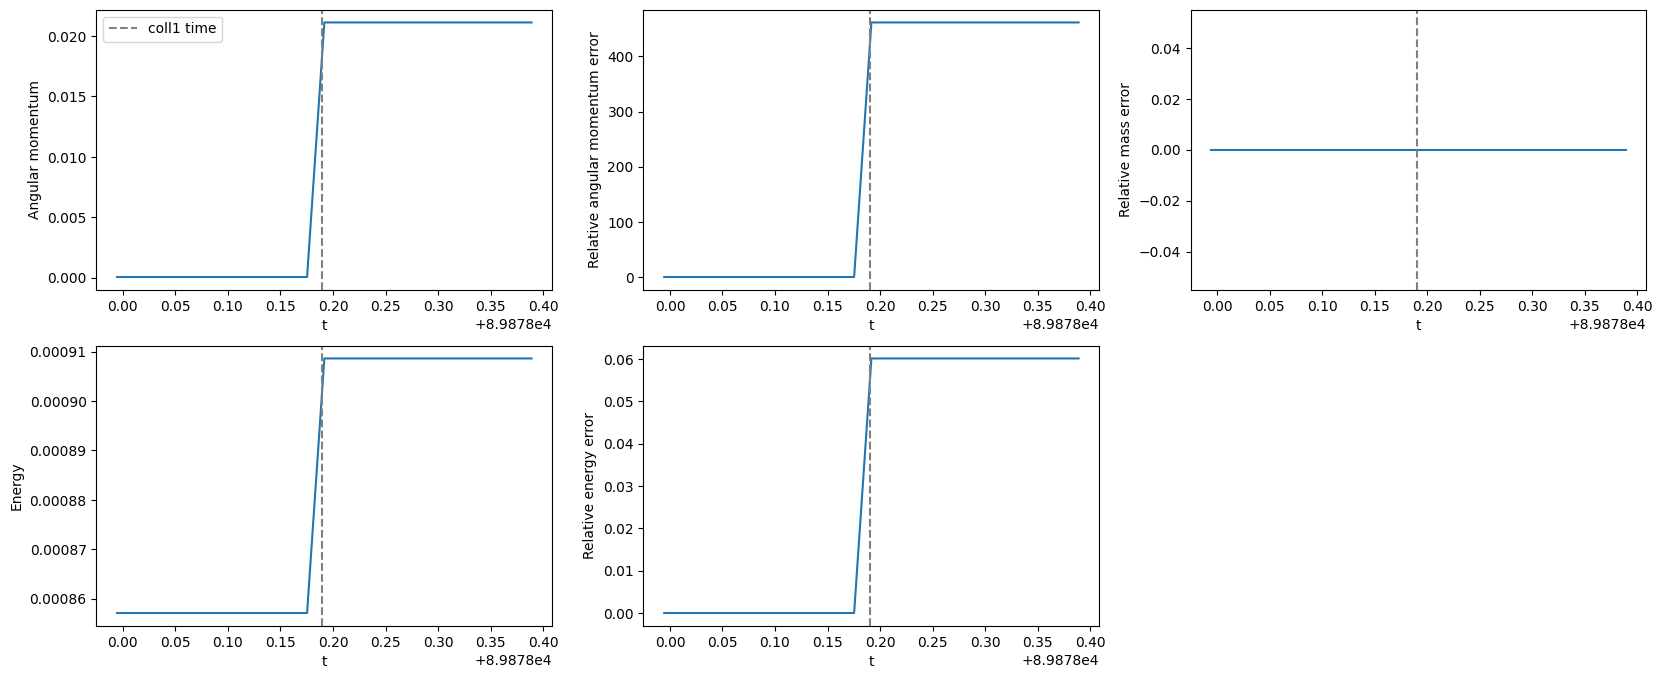

In [10]:
plt.figure(figsize=(20,8))
plt.subplot(2,3,1)
plt.plot(close_up['t'], close_up['angular_momentums'])
plt.xlabel('t')
plt.ylabel("Angular momentum")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')
plt.legend()

plt.subplot(2,3,2)
plt.plot(close_up['t'], close_up['L_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative angular momentum error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,3)
plt.plot(close_up['t'], close_up['m_errors'])
plt.xlabel('t')
plt.ylabel("Relative mass error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,4)
plt.plot(close_up['t'], close_up['E'])
plt.xlabel('t')
plt.ylabel("Energy")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

plt.subplot(2,3,5)
plt.plot(close_up['t'], close_up['E_rel_errors'])
plt.xlabel('t')
plt.ylabel("Relative energy error")
plt.axvline(t1, color = 'gray', linestyle = '--', label = 'coll1 time')

# Check velocities before and after collision: does the code give us what we expect?

In [11]:
idx_before = 497
idx_after = 498

snap_before = trace_8_det_archive[497]
snap_after = trace_8_det_archive[498]

/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: Binary file was saved with a different version of REBOUND. Binary format might have changed.
  warnings.warn(message, RuntimeWarning)
/Users/honeyeah/miniconda3/envs/reboundx-env/lib/python3.14/site-packages/rebound/simulationarchive.py:150: RuntimeWarning: You have to reset function pointers after creating a reb_simulation struct with a binary file.
  warnings.warn(message, RuntimeWarning)


In [12]:
m_parent1 = coll_1['parent1_mass'].iloc[0]
m_parent2 = coll_1['parent2_mass'].iloc[0]
r_parent1 = coll_1['parent1_radius'].iloc[0]
r_parent2 = coll_1['parent2_radius'].iloc[0]

m_frag1 = coll_1['new_mass'].iloc[0]
m_frag2 = coll_1['new_mass'].iloc[1]
m_frag3 = coll_1['new_mass'].iloc[2]

In [13]:
for i in range(snap_before.N):
    particle = snap_before.particles[i]
    if np.isclose(particle.m, m_parent1, atol=1e-11):
        parent1_before = particle
        print("parent1 mass = ", particle.m)

    if np.isclose(particle.m, m_parent2, atol=1e-11):
        parent2_before = particle
        print("parent2 mass = ", particle.m)

parent1 mass =  3.610303517342687e-07
parent2 mass =  1.3439302235566334e-08


In [14]:
for i in range(snap_after.N):
    particle = snap_after.particles[i]
    if np.isclose(particle.m, m_frag1, atol=1e-11):
        frag1 = particle
        print("frag1 mass = ", particle.m)

    if np.isclose(particle.m, m_frag2, atol=1e-11):
        frag2 = particle
        print("frag2 mass = ", particle.m)

    if np.isclose(particle.m, m_frag3, atol=1e-11):
        frag3 = particle
        print("frag3 mass = ", particle.m)

lr_mass = np.max([frag1.m, frag2.m, frag3.m])
print("lr_mass = ", lr_mass)

# Since we can see by printing that lr is frag1, then we can save frag2 and 3 as small frags
small_frags = [frag2, frag3]

frag1 mass =  2.0336529597486478e-07
frag2 mass =  6.18299255821101e-08
frag3 mass =  1.0927443241286017e-07
lr_mass =  2.0336529597486478e-07


In [22]:
# 1. Determine Target and Projectile based on mass (Target is >= Projectile)
if parent1_before.m >= parent2_before.m:
    target = parent1_before
    projectile = parent2_before
else:
    target = parent2_before
    projectile = parent1_before

initial_mass = target.m + projectile.m

# 2. Setup initial vectors
v_target = np.array([target.vx, target.vy, target.vz])
v_proj = np.array([projectile.vx, projectile.vy, projectile.vz])
r_target = np.array([target.x, target.y, target.z])
r_proj = np.array([projectile.x, projectile.y, projectile.z])

v_com = (target.m * v_target + projectile.m * v_proj) / initial_mass

# 3. Calculate internal expansion velocity 
# Note: Replicating the frame-dependent logic currently in the C code
v_lr = np.linalg.norm(v_com)

# 4. Relative vectors & Collision Plane
dv = v_target - v_proj
dr = r_target - r_proj
unit_dv = dv / np.linalg.norm(dv)

normal_coll_plane = np.cross(dv, dr)
mag_ncp = np.linalg.norm(normal_coll_plane)

# Collinear fallback (replicating C code lines 241-250)
if mag_ncp < 1e-15:
    arb_vec = np.cross(unit_dv, np.array([1.0, 0.0, 0.0]))
    if np.linalg.norm(arb_vec) < 1e-15:
        arb_vec = np.cross(unit_dv, np.array([0.0, 1.0, 0.0]))
    normal_coll_plane = arb_vec
    mag_ncp = np.linalg.norm(normal_coll_plane)

normal_coll_plane = normal_coll_plane / mag_ncp
normal_to_vrel = np.cross(dv, normal_coll_plane)
normal_to_vrel = normal_to_vrel / np.linalg.norm(normal_to_vrel)

# 5. Map fragments 
n_frag = len(small_frags) + 1
theta_sep = (2.0 * np.pi) / n_frag

# 6. Assign Initial Velocities and Track Momentum
mvsum = lr_mass * v_com 
target_v_raw = v_com 

frag_velocities_raw = []

for j, frag in enumerate(small_frags, start=1):
    frag_velocity_mag = v_lr * np.sqrt(lr_mass / frag.m)
    print("j = ", j)
    print(frag_velocity_mag)
    
    cos_t = np.cos(theta_sep * j)
    sin_t = np.sin(theta_sep * j)
    
    v_frag_raw = v_com + frag_velocity_mag * (cos_t * unit_dv + sin_t * normal_to_vrel)
    frag_velocities_raw.append({'mass': frag.m, 'v_raw': v_frag_raw})
    
    mvsum += frag.m * v_frag_raw

# 7. Momentum Offset Correction 
voff = v_com - (mvsum / initial_mass)

target_v_final = target_v_raw + voff #* (lr_mass / initial_mass)
print(f"Largest Remnant Expected v: {target_v_final}, abs = {get_abs(target_v_final[0], target_v_final[1], target_v_final[2])}")

for j, frag_dict in enumerate(frag_velocities_raw):
    v_frag_final = frag_dict['v_raw'] + voff #* (frag_dict['mass'] / initial_mass)
    print(f"Small Fragment {j+2} Expected v: {v_frag_final}, abs = {get_abs(v_frag_final[0], v_frag_final[1], v_frag_final[2])}")

j =  1
23.544218556262567
j =  2
17.71023658345258
Largest Remnant Expected v: [-15.96759098  -4.65809821   0.50204448], abs = 16.640729832674253
Small Fragment 2 Expected v: [-28.79022618  14.95775077  -1.76262393], abs = 32.49181858128611
Small Fragment 3 Expected v: [ 1.70097514 -3.65746644  1.18978495], abs = 4.20546851277673


com.x = 1.968260e+05, com.y = 2.022668e+05, com.z = -3.244424e+04
com.vx = -1.183108e+01, com.vy = -1.120538e+01, com.vz = 1.067790e+00

In [23]:
v_com

array([-12.92889361,  -1.12726484,   0.32880793])

In [28]:
r_com = (target.m * np.array(target.xyz) + projectile.m * np.array(projectile.xyz)) / initial_mass
r_com

array([1.21551403, 1.05751923, 0.10351652])

In [16]:
print(f"parent1 vx = {parent1_before.vx}, vy = {parent1_before.vy}, vz = {parent1_before.vz}")
print(f"parent2 vx = {parent2_before.vx}, vy = {parent2_before.vy}, vz = {parent2_before.vz}")
print(f"frag1 vx = {frag1.vx}, vy = {frag1.vy}, vz = {frag1.vz}, |v| = {get_abs(frag1.vx, frag1.vy, frag1.vz)}")
print(f"frag2 vx = {frag2.vx}, vy = {frag2.vy}, vz = {frag2.vz}, |v| = {get_abs(frag2.vx, frag2.vy, frag2.vz)}")
print(f"frag3 vx = {frag3.vx}, vy = {frag3.vy}, vz = {frag3.vz}, |v| = {get_abs(frag3.vx, frag3.vy, frag3.vz)}")

parent1 vx = -13.137913776570347, vy = -1.5377356191382705, vz = 0.35527063169252837
parent2 vx = -7.313823415689315, vy = 9.899528702734766, vz = -0.38208003425935105
frag1 vx = -10.308906797297643, vy = -13.328574206670242, vz = 1.1969418869610027, |v| = 16.892516675109324
frag2 vx = 15.089986674333467, vy = 3.927260784353003, vz = 0.7488105588039432, |v| = 15.61063074807853
frag3 vx = -27.264676515236626, vy = -24.576689927651636, vz = 1.4831872965579143, |v| = 36.73657738327156


# Check n_frag

In [17]:
def reb_random_powerlaw(m_min, m_max, slope):
    """
    Generates a random mass from a power-law distribution P(m) ~ m^(-slope).
    """
    y = np.random.uniform(0, 1)
    
    # Handle the slope == 1 edge case (logarithmic) just in case, 
    # though your code hardcodes slope = 3.
    if np.isclose(slope, 1.0):
        return m_min * np.exp(y * np.log(m_max / m_min))
    else:
        a = 1.0 - slope
        return (y * (m_max**a - m_min**a) + m_min**a) ** (1.0 / a)


def get_fragment_masses(lr_mass, slr_mass, remaining_mass, min_frag_mass):
    """
    Calculates the distribution of fragment masses and returns the list of 
    fragment masses along with the total count (n_frag).
    """
    # 1. Determine maximum fragment mass
    if slr_mass > 0:
        max_frag_mass = 0.5 * slr_mass
    else:
        max_frag_mass = 0.5 * lr_mass

    powerlaw_slope = 3.0
    m_frags = []
    sum_m_frags = 0.0

    # 2. Draw until we reach above the remaining mass
    while sum_m_frags < remaining_mass and len(m_frags) < 10000:
        frag_m = reb_random_powerlaw(min_frag_mass, max_frag_mass, powerlaw_slope)
        m_frags.append(frag_m)
        sum_m_frags += frag_m

    # 3. Handle outcomes based on fragment count
    if len(m_frags) >= 10000:
        raise ValueError(
            "Number of fragments produced is above permitted value (10000). "
            "Increase minimum fragment mass."
        )
        
    elif len(m_frags) == 1:
        m_frags[0] = remaining_mass
        
    elif len(m_frags) > 1:
        # Discard the last fragment
        discarded_frag = m_frags.pop()
        sum_m_frags -= discarded_frag
        
        # Distribute the mass scaling ratio between the remaining fragments
        ratio = remaining_mass / sum_m_frags
        m_frags = [m * ratio for m in m_frags]

    n_frag = len(m_frags)
    
    return m_frags, n_frag